In [1]:
import os
import re
import json
import string
import random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import clone_model
from tensorflow.keras.applications import EfficientNetV2B0
from sklearn.metrics import accuracy_score, classification_report
from transformers import AutoModel, TFAutoModel, AutoTokenizer, BertTokenizer
from PIL import Image
import pandas as pd
from sklearn.model_selection import train_test_split

2025-08-16 12:45:49.228334: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# data prep

In [2]:
df = pd.read_csv('click-id/dataset_with_image/combined_final_final.csv')
df = df[['title','content','image_path_processed','label_score']]
df.head(3)

,title,content,image_path_processed,label_score
0,"Masuk Radar Pilwalkot Medan, Menantu Jokowi Be...","Medan - Menantu Jokowi, Bobby Afif Nasution, m...",/content/drive/MyDrive/click-id/processed_imag...,0
1,Malaysia Sudutkan RI: Isu Kabut Asap hingga In...,Jakarta - Malaysia kembali menyerang pemerinta...,/content/drive/MyDrive/click-id/processed_imag...,0
2,Viral! Driver Ojol di Bekasi Antar Pesanan Mak...,Bekasi - Seorang driver ojek online di Bekasi ...,/content/drive/MyDrive/click-id/processed_imag...,1


In [3]:
class_counts = df['label_score'].value_counts()
print(class_counts)
min_class_size = class_counts.min()
balanced_dfs = []
for class_label in class_counts.index:
    class_df = df[df['label_score'] == class_label]
    if len(class_df) > min_class_size:
        sampled_df = class_df.sample(n=min_class_size, random_state=93)
    else:
        sampled_df = class_df
    balanced_dfs.append(sampled_df)
balanced_df = pd.concat(balanced_dfs, ignore_index=True)
print(balanced_df['label_score'].value_counts())

label_score
0    7959
1    6009
Name: count, dtype: int64
label_score
0    6009
1    6009
Name: count, dtype: int64


In [4]:
tokenizer = BertTokenizer.from_pretrained("indobenchmark/indobert-base-p1")

In [5]:
df_train, df_val = train_test_split(balanced_df, test_size = 0.2, stratify=balanced_df["label_score"].values, random_state = 93)
print(df_train.shape, df_val.shape)
print(df_train['label_score'].value_counts())
print(df_val['label_score'].value_counts())

(9614, 4) (2404, 4)
label_score
1    4807
0    4807
Name: count, dtype: int64
label_score
0    1202
1    1202
Name: count, dtype: int64


In [6]:
tokens_train = {
   'title':tokenizer.batch_encode_plus(
    df_train['title'].tolist(),
    max_length = 32,
    padding = 'max_length',
    truncation = True
   ),
    'content':tokenizer.batch_encode_plus(
    df_train['content'].tolist(),
    max_length = 128,
    padding = 'max_length',
    truncation = True
   )
}

tokens_val = {
  'title' : tokenizer.batch_encode_plus(
    df_val['title'].tolist(),
    max_length = 32,
    padding = 'max_length',
    truncation=True
  ),
  'content' : tokenizer.batch_encode_plus(
    df_val['content'].tolist(),
    max_length = 128,
    padding = 'max_length',
    truncation=True
  )
}

In [7]:
IMG_HEIGHT = 224
IMG_WIDTH = 224

def load_and_preprocess_images(image_paths):
    images = []
    n = 0
    for path in image_paths:
        n = n+1
        newpath = "/".join(i for i in path.split("/")[-4:])
        # print(newpath)
        img = tf.io.read_file(newpath)
        img = tf.image.decode_image(img, channels=3)
        # img = tf.cast(img, tf.float32)
        # img = img/255.0

        images.append(img)
        if n%100 == 0:
          print(n,'images processed')
    return tf.stack(images)

with tf.device("/cpu:0"):
    train_images = load_and_preprocess_images(df_train['image_path_processed'].tolist())
    val_images = load_and_preprocess_images(df_val['image_path_processed'].tolist())

2025-08-16 12:46:32.086464: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:05:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-08-16 12:46:32.162814: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:05:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-08-16 12:46:32.162862: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:05:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-08-16 12:46:32.164882: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:05:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-08-16 12:46:32.164927: I external/local_xla/xla/stream_executor

100 images processed
200 images processed
300 images processed
400 images processed
500 images processed
600 images processed
700 images processed
800 images processed
900 images processed
1000 images processed
1100 images processed
1200 images processed
1300 images processed
1400 images processed
1500 images processed
1600 images processed
1700 images processed
1800 images processed
1900 images processed
2000 images processed
2100 images processed
2200 images processed
2300 images processed
2400 images processed
2500 images processed
2600 images processed
2700 images processed
2800 images processed
2900 images processed
3000 images processed
3100 images processed
3200 images processed
3300 images processed
3400 images processed
3500 images processed
3600 images processed
3700 images processed
3800 images processed
3900 images processed
4000 images processed
4100 images processed
4200 images processed
4300 images processed
4400 images processed
4500 images processed
4600 images process

In [8]:
with tf.device("/cpu:0"):
    def save_tf_dataset(images, filename):
        dataset = tf.data.Dataset.from_tensor_slices(images)
        
        tf.data.Dataset.save(dataset, filename)
        print(f"Dataset saved to {filename}")
    
    # Save the datasets
    save_tf_dataset(train_images, "./balanced_train_images_dataset")
    save_tf_dataset(val_images, "./balanced_val_images_dataset")

Dataset saved to ./balanced_train_images_dataset
Dataset saved to ./balanced_val_images_dataset


In [9]:
train_images = tf.data.Dataset.load("balanced_train_images_dataset")
val_images = tf.data.Dataset.load("balanced_val_images_dataset")

In [10]:
train_data = {
    'title':tf.squeeze(tf.convert_to_tensor(tokens_train['title']['input_ids'])),
    'content':tf.squeeze(tf.convert_to_tensor(tokens_train['content']['input_ids'])),
    'titlemask':tf.squeeze(tf.convert_to_tensor(tokens_train['title']['attention_mask'])),
    'contentmask':tf.squeeze(tf.convert_to_tensor(tokens_train['content']['attention_mask'])),
}

validation_data = {
    'title':tf.convert_to_tensor(tokens_val['title']['input_ids']),
    'content':tf.convert_to_tensor(tokens_val['content']['input_ids']),
    'titlemask':tf.convert_to_tensor(tokens_val['title']['attention_mask']),
    'contentmask':tf.convert_to_tensor(tokens_val['content']['attention_mask']),
}


label_train = tf.convert_to_tensor(df_train['label_score'].tolist())
label_val = tf.convert_to_tensor(df_val['label_score'].tolist())

In [11]:
dataset = (tf.data.Dataset.from_tensor_slices((dict(train_data),label_train))
    .prefetch(tf.data.AUTOTUNE)
    .cache()
    )
dataVal = (tf.data.Dataset.from_tensor_slices((dict(validation_data),label_val))
    .prefetch(tf.data.AUTOTUNE)
    .cache()
    )

dataset = tf.data.Dataset.zip((dataset, train_images))
dataVal = tf.data.Dataset.zip((dataVal, val_images))

def add_image_and_fix_shapes(text_data_label, image):
    text_data, label = text_data_label
    new_data = {
        'title': tf.ensure_shape(text_data['title'], [None, 32]),
        'content': tf.ensure_shape(text_data['content'], [None, 128]),
        'titlemask': tf.ensure_shape(text_data['titlemask'], [None, 32]),
        'contentmask': tf.ensure_shape(text_data['contentmask'], [None, 128]),
        'image': image
    }
    
    return new_data, label

dataset = (dataset
    .batch(32)
    .map(add_image_and_fix_shapes)
    .prefetch(tf.data.AUTOTUNE)
    .cache()
)

dataVal = (dataVal
    .batch(32)
    .map(add_image_and_fix_shapes)
    .prefetch(tf.data.AUTOTUNE)
    .cache()
)


In [12]:
tf.data.Dataset.save(dataset, "./balanced_dataset")
tf.data.Dataset.save(dataVal, "./balanced_dataVal")

# after data prep

In [13]:
dataset = tf.data.Dataset.load(
    "balanced_dataset",
    element_spec=({
        'title': tf.TensorSpec(shape=(None, 32), dtype=tf.int32),
        'content': tf.TensorSpec(shape=(None, 128), dtype=tf.int32),
        'titlemask': tf.TensorSpec(shape=(None, 32), dtype=tf.int32),
        'contentmask': tf.TensorSpec(shape=(None, 128), dtype=tf.int32),
        'image': tf.TensorSpec(shape=(None, 224, 224, 3), dtype=tf.uint8)
    }, tf.TensorSpec(shape=(None,), dtype=tf.int32))
)

dataVal = tf.data.Dataset.load(
    "balanced_dataVal",
    element_spec=({
        'title': tf.TensorSpec(shape=(None, 32), dtype=tf.int32),
        'content': tf.TensorSpec(shape=(None, 128), dtype=tf.int32),
        'titlemask': tf.TensorSpec(shape=(None, 32), dtype=tf.int32),
        'contentmask': tf.TensorSpec(shape=(None, 128), dtype=tf.int32),
        'image': tf.TensorSpec(shape=(None, 224, 224, 3), dtype=tf.uint8)
    }, tf.TensorSpec(shape=(None,), dtype=tf.int32))
)

In [14]:
class BertEmbeddingLayer(tf.keras.layers.Layer):
    def __init__(self, model_name, **kwargs):
        super(BertEmbeddingLayer, self).__init__(**kwargs)
        self.model_name = model_name
        self.embedding_size = None
        self.bert = None

    def build(self, input_shape):
        self.bert = TFAutoModel.from_pretrained(self.model_name)
        self.bert.trainable = True
        self.embedding_size = self.bert.config.hidden_size
        super(BertEmbeddingLayer, self).build(input_shape)

    def call(self, inputs):
        ids, att = inputs
        outputs = self.bert(input_ids=ids, attention_mask=att)
        return outputs.pooler_output

    def get_config(self):
        config = super(BertEmbeddingLayer, self).get_config()
        config.update({
            "model_name": self.model_name
        })
        return config
    
    @classmethod
    def from_config(cls, config):
        clean_config = {k: v for k, v in config.items() 
                      if k in ['model_name', 'name', 'trainable', 'dtype']}
        return cls(**clean_config)

In [15]:
def makemodel(output_bias=None):
    # Text using IndoBertp1
    ids1 = tf.keras.layers.Input(shape=(32,), dtype=tf.int32, name="title")
    att1 = tf.keras.layers.Input(shape=(32,), dtype=tf.int32, name="titlemask")
    ids2 = tf.keras.layers.Input(shape=(128,), dtype=tf.int32, name="content")
    att2 = tf.keras.layers.Input(shape=(128,), dtype=tf.int32, name="contentmask")

    indobert1 = BertEmbeddingLayer(model_name="indobenchmark/indobert-base-p1", name="indobert1")
    indobert2 = BertEmbeddingLayer(model_name="indobenchmark/indobert-base-p1", name="indobert2")

    title = indobert1([ids1, att1])
    content = indobert2([ids2, att2])

    # Image using EfficientNetV2s
    img1 = tf.keras.layers.Input(shape=(224,224,3), dtype=tf.uint8, name="image")

    effi = EfficientNetV2B0(
        include_top = False,
        weights = 'imagenet',
        input_shape = (224,224,3),
        pooling = 'max'
    )
    image = effi(img1)

    fin = tf.keras.layers.concatenate([title, content, image])
    fin = tf.keras.layers.BatchNormalization()(fin)
        
    fin = tf.keras.layers.Dense(512, activation=None)(fin)
    fin = tf.keras.layers.BatchNormalization()(fin)
    fin = tf.keras.layers.Activation('relu')(fin)
    fin = tf.keras.layers.Dropout(0.4)(fin) 

    fin = tf.keras.layers.Dense(256, activation=None)(fin)
    fin = tf.keras.layers.BatchNormalization()(fin)
    fin = tf.keras.layers.Activation('relu')(fin)
    fin = tf.keras.layers.Dropout(0.4)(fin) 
    
    fin = tf.keras.layers.Dense(128, activation=None)(fin)
    fin = tf.keras.layers.BatchNormalization()(fin)
    fin = tf.keras.layers.Activation('relu')(fin)
    fin = tf.keras.layers.Dropout(0.4)(fin) 
    
    fin = tf.keras.layers.Dense(64, activation='relu')(fin)
    fin = tf.keras.layers.Dropout(0.2)(fin)
    fin = tf.keras.layers.Dense(1, activation='sigmoid')(fin)

    final = tf.keras.Model(inputs=[ids1, att1, ids2, att2, img1], outputs=fin)

    for layer in final.layers:
      layer.trainable = True
    optimizer = tf.keras.optimizers.Adam(learning_rate = 0.00005)
    final.compile(
        loss = tf.keras.losses.BinaryCrossentropy(),
        optimizer=optimizer,
        metrics=[tf.keras.metrics.BinaryAccuracy(),tf.keras.metrics.Precision(),tf.keras.metrics.Recall()]
    )

    return final

final = makemodel()
final.summary()

Some layers from the model checkpoint at indobenchmark/indobert-base-p1 were not used when initializing TFBertModel: ['nsp___cls', 'mlm___cls', 'bert/embeddings/LayerNorm/beta:0', 'bert/encoder/layer_._2/output/LayerNorm/beta:0', 'bert/encoder/layer_._6/attention/self/value/kernel:0', 'bert/encoder/layer_._0/attention/output/LayerNorm/beta:0', 'bert/encoder/layer_._2/attention/output/LayerNorm/beta:0', 'bert/encoder/layer_._0/attention/output/dense/kernel:0', 'bert/encoder/layer_._3/attention/output/dense/kernel:0', 'bert/encoder/layer_._3/output/dense/kernel:0', 'bert/encoder/layer_._3/attention/output/LayerNorm/gamma:0', 'bert/encoder/layer_._2/intermediate/dense/kernel:0', 'bert/encoder/layer_._5/intermediate/dense/bias:0', 'bert/encoder/layer_._11/attention/output/dense/bias:0', 'bert/encoder/layer_._9/intermediate/dense/bias:0', 'bert/encoder/layer_._7/attention/self/key/kernel:0', 'bert/encoder/layer_._6/output/LayerNorm/gamma:0', 'bert/embeddings/word_embeddings/weight:0', 'bert

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ title (InputLayer)  │ (None, 32)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ titlemask           │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ content             │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ contentmask         │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ indobert1           │ (None, 768)       │          0 │ title[0][0],      │
│ (BertEmbeddingLaye… │                   │            │ titlemask[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ indobert2           │ (None, 768)       │          0 │ content[0][0],    │
│ (BertEmbeddingLaye… │                   │            │ contentmask[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetv2-b0   │ (None, 1280)      │  5,919,312 │ image[0][0]       │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2816)      │          0 │ indobert1[0][0],  │
│ (Concatenate)       │                   │            │ indobert2[0][0],  │
│                     │                   │            │ efficientnetv2-b… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2816)      │     11,264 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,442,304 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 512)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ activation_1[0][

 Total params: 7,549,009 (28.80 MB)

 Trainable params: 7,480,977 (28.54 MB)

 Non-trainable params: 68,032 (265.75 KB)

In [16]:
tf.keras.mixed_precision.set_global_policy('mixed_float16')

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
    )

# model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
#     filepath='./models/best_model_val_loss_{val_loss:.4f}.weights.h5',
#     monitor='val_loss',
#     save_best_only=True,
#     save_weights_only=True
# )

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=1,
    min_lr=1e-8
)

history=final.fit(x = dataset,
                  epochs = 50,
                  callbacks=[early_stopping, 
                             # model_checkpoint, 
                             reduce_lr],
                  validation_data=dataVal
                  )

Epoch 1/50


I0000 00:00:1755323285.000246   68788 service.cc:145] XLA service 0x7d9d200141f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1755323285.000291   68788 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 3070, Compute Capability 8.6
2025-08-16 12:48:06.589888: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
W0000 00:00:1755323287.518933   68788 assert_op.cc:38] Ignoring Assert operator functional_1/indobert1_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert
W0000 00:00:1755323287.615418   68788 assert_op.cc:38] Ignoring Assert operator functional_1/indobert2_1/tf_bert_model_1/bert/embeddings/assert_less/Assert/Assert
2025-08-16 12:48:12.767146: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1755323309.902309   69314 asm_compiler.cc:369] ptxas warning :

300/301 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - binary_accuracy: 0.5211 - loss: 0.7757 - precision: 0.5229 - recall: 0.5932

W0000 00:00:1755323394.335020   68786 assert_op.cc:38] Ignoring Assert operator functional_1/indobert1_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert
W0000 00:00:1755323394.340321   68786 assert_op.cc:38] Ignoring Assert operator functional_1/indobert2_1/tf_bert_model_1/bert/embeddings/assert_less/Assert/Assert
I0000 00:00:1755323412.603760   69408 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_7', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1755323412.789085   69412 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_7', 20 bytes spill stores, 20 bytes spill loads

I0000 00:00:1755323412.879408   69409 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_7', 96 bytes spill stores, 96 bytes spill loads

I0000 00:00:1755323412.972325   69403 asm_compiler.cc:369] ptxas warning : Registers are spilled to loc

301/301 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - binary_accuracy: 0.5211 - loss: 0.7757 - precision: 0.5229 - recall: 0.5932

W0000 00:00:1755323456.954766   68786 assert_op.cc:38] Ignoring Assert operator functional_1/indobert1_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert
W0000 00:00:1755323457.020076   68786 assert_op.cc:38] Ignoring Assert operator functional_1/indobert2_1/tf_bert_model_1/bert/embeddings/assert_less/Assert/Assert
I0000 00:00:1755323459.090600   69637 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_13839', 8 bytes spill stores, 8 bytes spill loads

W0000 00:00:1755323469.583441   68789 assert_op.cc:38] Ignoring Assert operator functional_1/indobert1_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert
W0000 00:00:1755323469.588414   68789 assert_op.cc:38] Ignoring Assert operator functional_1/indobert2_1/tf_bert_model_1/bert/embeddings/assert_less/Assert/Assert
I0000 00:00:1755323471.740197   69703 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_2', 96 bytes spil

301/301 ━━━━━━━━━━━━━━━━━━━━ 241s 419ms/step - binary_accuracy: 0.5211 - loss: 0.7756 - precision: 0.5230 - recall: 0.5931 - val_binary_accuracy: 0.6023 - val_loss: 0.6689 - val_precision: 0.7071 - val_recall: 0.3494 - learning_rate: 5.0000e-05
Epoch 2/50
301/301 ━━━━━━━━━━━━━━━━━━━━ 48s 160ms/step - binary_accuracy: 0.5847 - loss: 0.7010 - precision: 0.5921 - recall: 0.5713 - val_binary_accuracy: 0.6585 - val_loss: 0.6242 - val_precision: 0.7239 - val_recall: 0.5125 - learning_rate: 5.0000e-05
Epoch 3/50
301/301 ━━━━━━━━━━━━━━━━━━━━ 46s 153ms/step - binary_accuracy: 0.6244 - loss: 0.6664 - precision: 0.6294 - recall: 0.6242 - val_binary_accuracy: 0.6809 - val_loss: 0.6012 - val_precision: 0.7356 - val_recall: 0.5649 - learning_rate: 5.0000e-05
Epoch 4/50
301/301 ━━━━━━━━━━━━━━━━━━━━ 46s 153ms/step - binary_accuracy: 0.6434 - loss: 0.6375 - precision: 0.6519 - recall: 0.6310 - val_binary_accuracy: 0.6918 - val_loss: 0.5863 - val_precision: 0.7374 - val_recall: 0.5957 - learning_rate: 5

In [17]:
y_pred = final.predict(dataVal)
y_pred_binary = (y_pred > 0.5).astype(int)
from sklearn.metrics import classification_report
y_val = np.concatenate([y for _, y in dataVal.as_numpy_iterator()])
print(classification_report(y_val, y_pred_binary, 
                           target_names=['Class_0', 'Class_1'],
                           digits = 4))

W0000 00:00:1755324048.973725   68789 assert_op.cc:38] Ignoring Assert operator functional_1/indobert1_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert
W0000 00:00:1755324049.014209   68789 assert_op.cc:38] Ignoring Assert operator functional_1/indobert2_1/tf_bert_model_1/bert/embeddings/assert_less/Assert/Assert


75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step

W0000 00:00:1755324065.231604   68784 assert_op.cc:38] Ignoring Assert operator functional_1/indobert1_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert
W0000 00:00:1755324065.323909   68784 assert_op.cc:38] Ignoring Assert operator functional_1/indobert2_1/tf_bert_model_1/bert/embeddings/assert_less/Assert/Assert


76/76 ━━━━━━━━━━━━━━━━━━━━ 27s 249ms/step
              precision    recall  f1-score   support

     Class_0     0.6859    0.8012    0.7391      1202
     Class_1     0.7610    0.6331    0.6912      1202

    accuracy                         0.7171      2404
   macro avg     0.7234    0.7171    0.7151      2404
weighted avg     0.7234    0.7171    0.7151      2404



2025-08-16 13:01:12.376304: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


dict_keys(['binary_accuracy', 'loss', 'precision', 'recall', 'val_binary_accuracy', 'val_loss', 'val_precision', 'val_recall', 'learning_rate'])
Final training loss: 0.4346708655357361


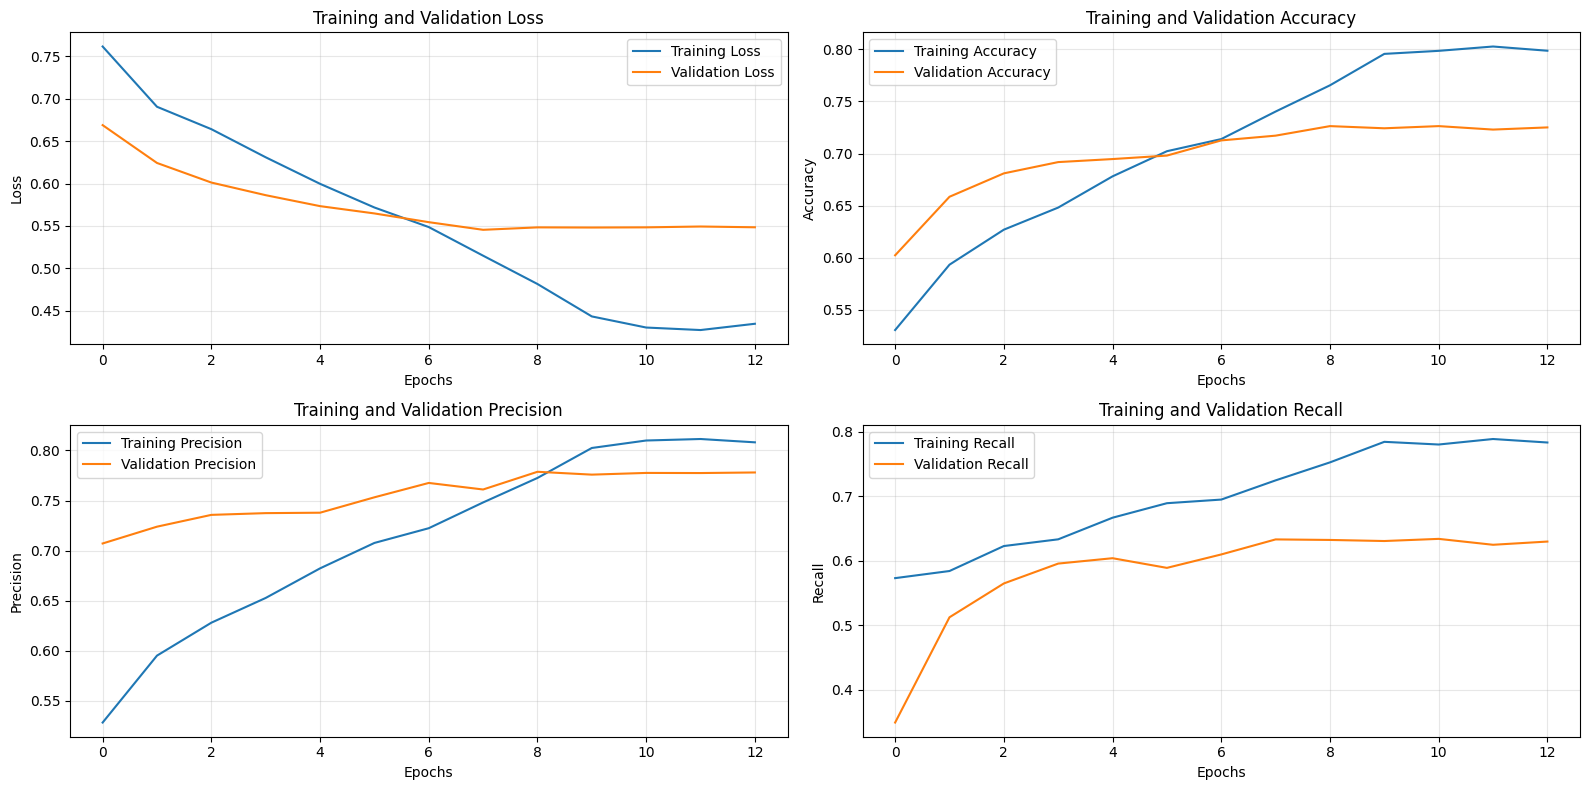


FINAL METRICS SUMMARY
Loss           : Train = 0.4347, Val = 0.5484
Binary_accuracy: Train = 0.7986, Val = 0.7250
Precision      : Train = 0.8081, Val = 0.7780
Recall         : Train = 0.7832, Val = 0.6298


In [18]:
print(history.history.keys())
final_loss = history.history['loss'][-1]
print(f"Final training loss: {final_loss}")

import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))
plt.subplot(2, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

if 'binary_accuracy' in history.history:
    plt.subplot(2, 2, 2)
    plt.plot(history.history['binary_accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_binary_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

if 'precision' in history.history:
    plt.subplot(2, 2, 3)
    plt.plot(history.history['precision'], label='Training Precision')
    plt.plot(history.history['val_precision'], label='Validation Precision')
    plt.xlabel('Epochs')
    plt.ylabel('Precision')
    plt.title('Training and Validation Precision')
    plt.legend()
    plt.grid(True, alpha=0.3)

if 'recall' in history.history:
    plt.subplot(2, 2, 4)
    plt.plot(history.history['recall'], label='Training Recall')
    plt.plot(history.history['val_recall'], label='Validation Recall')
    plt.xlabel('Epochs')
    plt.ylabel('Recall')
    plt.title('Training and Validation Recall')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("FINAL METRICS SUMMARY")
print("="*50)

metrics_to_show = ['loss', 'binary_accuracy', 'precision', 'recall']
for metric in metrics_to_show:
    if metric in history.history:
        train_val = history.history[metric][-1]
        val_key = f'val_{metric}'
        val_val = history.history[val_key][-1] if val_key in history.history else None
        
        print(f"{metric.capitalize():15}: Train = {train_val:.4f}", end="")
        if val_val is not None:
            print(f", Val = {val_val:.4f}")
        else:
            print()